In [7]:
import numpy as np                #number handling suite
import pandas as pd               #also handles numbers and is a pre-requisite for geopandas
import os                         #for commands around file management
import geopandas as gpd           #geospatial pandas suite
import shapely                    #shapefile manager
from shapely.geometry.polygon import Polygon

from osgeo import gdal            #a way to visualise and load .tiff files
import matplotlib.pyplot as plt   #main plotting module for python

!pip install cartopy              #Map tools module
import cartopy
import cartopy.crs as ccrs

from google.colab import files

In [8]:
#Import DEM map
gdal.UseExceptions() #necessary for gdal
resolution = 1/4 #set's the resolution of the map, 1/4 = 40075/360/4, one quarter of a degree ~27 km per pixel

kwargs = {'xRes':resolution, 'yRes':resolution,} #set the resolution to warp
scs = gdal.Warp("scaled_dem.tif", "https://www.ngdc.noaa.gov/mgg/global/relief/ETOPO2022/data/60s/60s_bed_elev_gtif/ETOPO_2022_v1_60s_N90W180_bed.tif", **kwargs) #load the full size DEM and then convert it
#do the conversion of a tiff to image
band = scs.GetRasterBand(1)
dem = band.ReadAsArray()
print(dem.shape)

(720, 1440)


In [9]:
lon=np.linspace(-180,180,(len(dem[0]))) #make an array of variables of length 1440 starting at -180 and ending at 180 to use as the x-axis or columns
print(lon.shape)

(1440,)


In [10]:
lat=np.linspace(90,-90,len(dem)) #make an array of variables of length 720 starting at 90 and ending at -90 to use as the y-axis or rows
print(lat.shape)

(720,)


(110.0, 165.0)

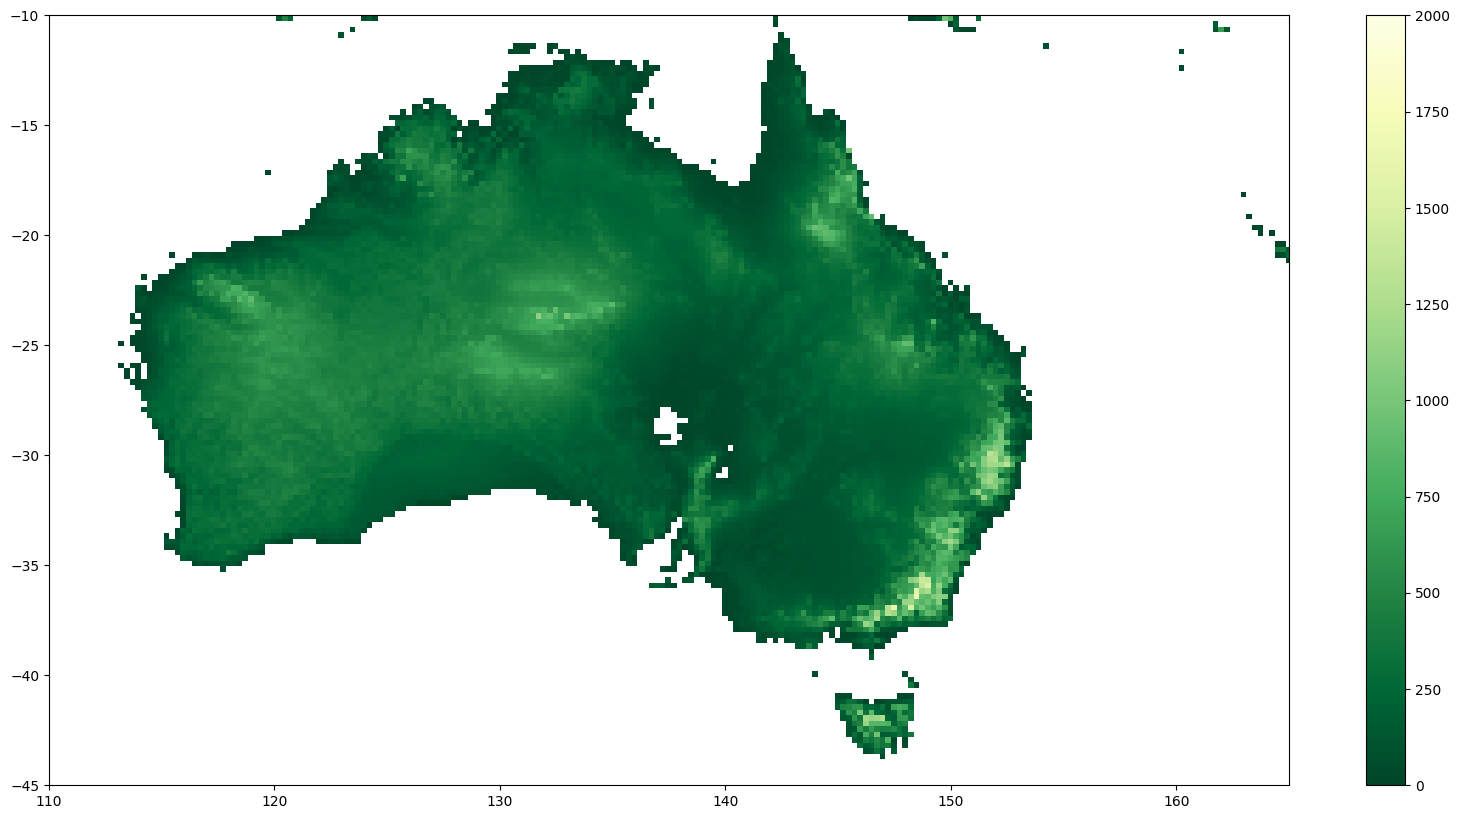

In [33]:
fig, ax = plt.subplots(figsize=(20, 10))
plt.pcolormesh(lon, lat, np.ma.masked_where(dem<=0, dem), cmap="YlGn_r") #plot a pcolormesh and mask out the ocean to be white, then set inverse yellow-green colormap
plt.clim(0,2000) #limit the max value to better visualise the elevation
plt.colorbar()
#set the limits of the plot to YOUR CHOSEN POSITION
plt.ylim(-45,-10)
plt.xlim(110,165)
